In [1]:
EUROSAT_ROOT = '/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT'
UCMERCED_ROOT = '/kaggle/input/datasets/abdulhasibuddin/uc-merced-land-use-dataset/UCMerced_LandUse/Images'

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

np.random.seed(42)

eurosat_root = Path(EUROSAT_ROOT)
classes = sorted([d.name for d in eurosat_root.iterdir() if d.is_dir()])
print("classes:", classes)

records = []
for c in classes:
    for f in (eurosat_root / c).glob('*.jpg'):
        records.append({'path': str(f), 'class': c})
df = pd.DataFrame(records)
print("total images:", len(df))
df.head()

classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
total images: 27000


,path,class
0,/kaggle/input/datasets/apollo2506/eurosat-data...,AnnualCrop
1,/kaggle/input/datasets/apollo2506/eurosat-data...,AnnualCrop
2,/kaggle/input/datasets/apollo2506/eurosat-data...,AnnualCrop
3,/kaggle/input/datasets/apollo2506/eurosat-data...,AnnualCrop
4,/kaggle/input/datasets/apollo2506/eurosat-data...,AnnualCrop


In [3]:
df['file_idx'] = df['path'].apply(lambda p: int(Path(p).stem.split('_')[-1]))
df['block_id'] = df['file_idx'] // 9

blocks = df['block_id'].unique()
np.random.shuffle(blocks)
n = len(blocks)
train_blocks = blocks[:int(0.7*n)]
val_blocks = blocks[int(0.7*n):int(0.85*n)]

df['split_block'] = df['block_id'].apply(
    lambda b: 'train' if b in train_blocks else ('val' if b in val_blocks else 'test')
)

df['split_random'] = np.random.choice(['train','val','test'], size=len(df), p=[0.7,0.15,0.15])

print(df['split_block'].value_counts())
print(df['split_random'].value_counts())

df.to_csv('/kaggle/working/manifest.csv', index=False)

split_block
train    18694
val       4175
test      4131
Name: count, dtype: int64
split_random
train    18918
test      4069
val       4013
Name: count, dtype: int64


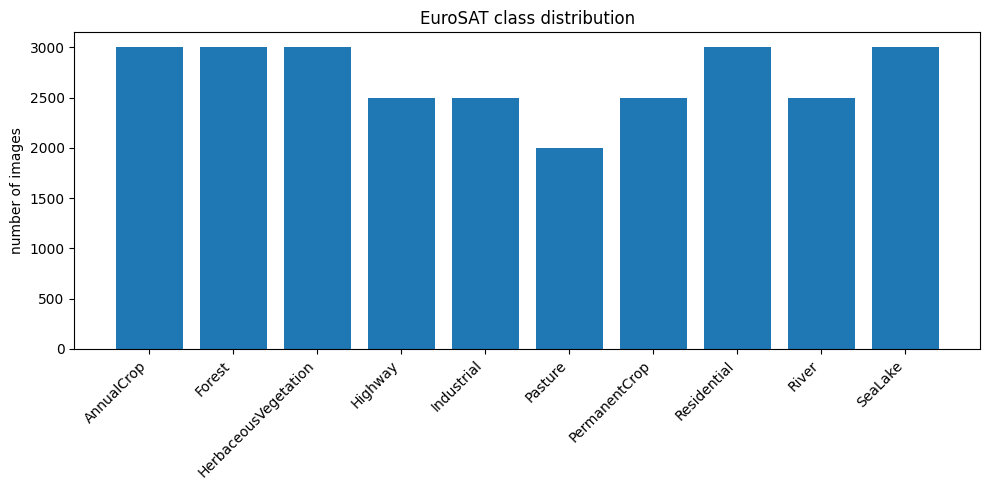

In [4]:
import matplotlib.pyplot as plt

counts = df['class'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('number of images')
plt.title('EuroSAT class distribution')
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.png')
plt.show()